# 23 · PSM validation — love plot and pre/post matching balance

Refit the propensity-score match on the full cohort with the same covariates used for the matched sub-cohort analyses (age, sex, disease duration, UPDRS-III, NHY, LEDD, BMI), then show the standardized mean differences (SMD) before and after matching via `cobalt::love.plot`. Output: love plot + balance table.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(MatchIt); library(cobalt); library(broom)
})
# Reconstruct one-row-per-patient baseline frame from full cohort
rel <- load_full_ppmi_rel_patient_anchor()
base <- rel %>% dplyr::filter(months >= -24, months <= 0) %>%
  dplyr::arrange(PATNO, dplyr::desc(months)) %>%
  dplyr::group_by(PATNO) %>% dplyr::slice_head(n = 1) %>% dplyr::ungroup() %>%
  dplyr::select(PATNO, will_receive_dbs, age_at_visit, SEX, duration_yrs,
                updrs3_score, NHY, LEDD, BMI, NP1PAIN) %>%
  tidyr::drop_na(age_at_visit, SEX, duration_yrs, updrs3_score, NHY, LEDD, BMI)
cat("Complete-case baseline n:", nrow(base), "\n")
print(dplyr::count(base, will_receive_dbs, name = "n"))

Warning message:
“package ‘broom’ was built under R version 4.5.2”


Complete-case baseline n: 971 


# A tibble: 2 × 2
  will_receive_dbs     n
  <lgl>            <int>
1 FALSE              918
2 TRUE                53


In [2]:
# Fit PSM: 1:2 nearest-neighbour on logistic propensity score
set.seed(42)
m <- MatchIt::matchit(
  will_receive_dbs ~ age_at_visit + SEX + duration_yrs + updrs3_score + NHY + LEDD + BMI,
  data = base, method = "nearest", ratio = 2, caliper = 0.2
)
print(summary(m))


Call:
MatchIt::matchit(formula = will_receive_dbs ~ age_at_visit + 
    SEX + duration_yrs + updrs3_score + NHY + LEDD + BMI, data = base, 
    method = "nearest", caliper = 0.2, ratio = 2)

Summary of Balance for All Data:
             Means Treated Means Control Std. Mean Diff. Var. Ratio eCDF Mean
distance            0.2404        0.0439          0.8362     7.5561    0.3848
age_at_visit       62.9471       64.3357         -0.1842     0.6448    0.0679
SEX                 0.6038        0.6285         -0.0506          .    0.0248
duration_yrs        2.0808        1.0601          0.4366     3.7347    0.1350
updrs3_score       38.5849       24.0599          0.7596     3.1000    0.2027
NHY                 2.2264        1.7549          0.5894     2.4268    0.0845
LEDD              665.6602      138.8387          1.1414     2.0917    0.3408
BMI                26.9071       88.0552        -11.8469     0.0000    0.0276
             eCDF Max
distance       0.7078
age_at_visit   0.1645
SEX    

In [3]:
# Balance table (cobalt)
b <- cobalt::bal.tab(m, un = TRUE, disp = c("means","sds"))
print(b)

bal_tbl <- as.data.frame(b$Balance) %>% tibble::rownames_to_column("covariate")
print(bal_tbl)
save_table(bal_tbl, "psm_balance_table")

Balance Measures
                 Type   M.0.Un   SD.0.Un   M.1.Un  SD.1.Un  Diff.Un  M.0.Adj
distance     Distance   0.0439    0.0855   0.2404   0.2351   0.8362   0.1897
age_at_visit  Contin.  64.3357    9.3895  62.9471   7.5396  -0.1842  62.7459
SEX            Binary   0.6285         .   0.6038        .  -0.0248   0.5417
duration_yrs  Contin.   1.0601    1.2096   2.0808   2.3376   0.4366   2.0966
updrs3_score  Contin.  24.0599   10.8609  38.5849  19.1225   0.7596  34.1562
NHY           Contin.   1.7549    0.5136   2.2264   0.8000   0.5894   2.0208
LEDD          Contin. 138.8387  319.1367 665.6602 461.5631   1.1414 674.6224
BMI           Contin.  88.0552 1853.9965  26.9071   5.1615 -11.8469  26.9535
             SD.0.Adj  M.1.Adj SD.1.Adj Diff.Adj
distance       0.1694   0.1908   0.1688   0.0046
age_at_visit   9.9344  63.2590   7.4232   0.0680
SEX                 .   0.6042        .   0.0625
duration_yrs   2.1543   2.0136   2.3000  -0.0355
updrs3_score  13.2494  35.9583  15.5686   0.0

     covariate     Type       M.0.Un      SD.0.Un      M.1.Un     SD.1.Un
1     distance Distance   0.04385319 8.551917e-02   0.2404297   0.2350786
2 age_at_visit  Contin.  64.33572686 9.389466e+00  62.9470664   7.5396383
3          SEX   Binary   0.62854031           NA   0.6037736          NA
4 duration_yrs  Contin.   1.06011281 1.209579e+00   2.0807961   2.3375690
5 updrs3_score  Contin.  24.05991285 1.086086e+01  38.5849057  19.1225139
6          NHY  Contin.   1.75490196 5.135598e-01   2.2264151   0.8000363
7         LEDD  Contin. 138.83865546 3.191367e+02 665.6602201 461.5631305
8          BMI  Contin.  88.05523927 1.853997e+03  26.9070803   5.1615363
       Diff.Un     M.0.Adj    SD.0.Adj     M.1.Adj    SD.1.Adj     Diff.Adj
1   0.83621643   0.1897034   0.1694144   0.1907841   0.1687601  0.004597194
2  -0.18418131  62.7458904   9.9344448  63.2589612   7.4232385  0.068049786
3  -0.02476672   0.5416667          NA   0.6041667          NA  0.062500000
4   0.43664306   2.0965753   2

Warning message:
“Large mean differences detected; you may not be using standardized mean
differences for continuous variables.”


Warning message:
“Standardized mean differences and raw mean differences are present in
the same plot. Use the `stars` argument to distinguish between them and
appropriately label the x-axis. See `?love.plot` for details.”


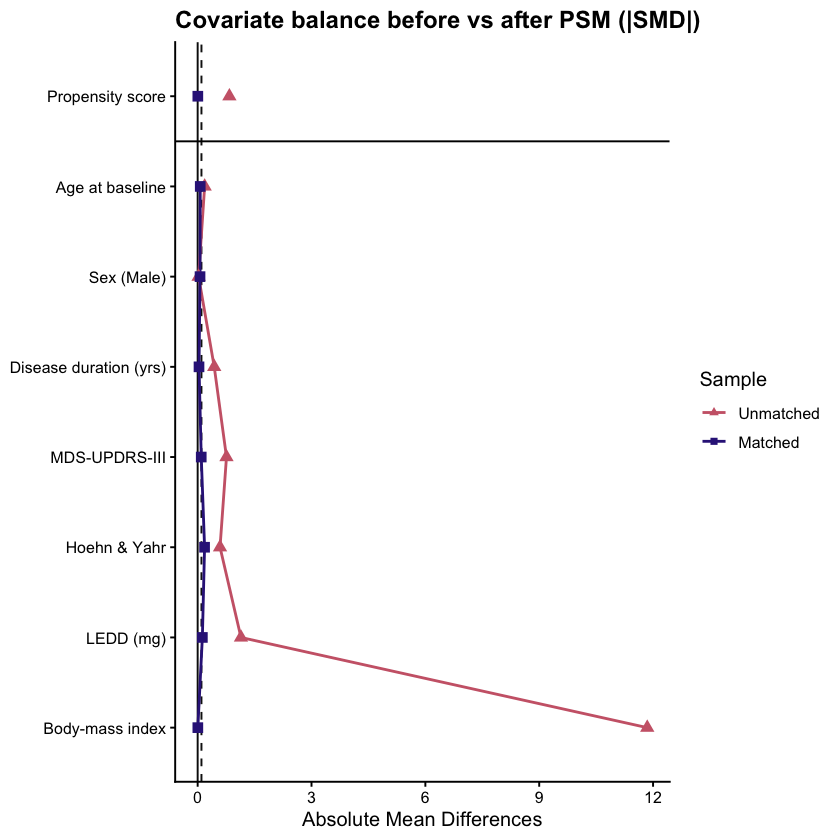

In [4]:
# Love plot — SMDs before and after matching
var_names <- c(age_at_visit = "Age at baseline",
               SEX          = "Sex (Male)",
               duration_yrs = "Disease duration (yrs)",
               updrs3_score = "MDS-UPDRS-III",
               NHY          = "Hoehn & Yahr",
               LEDD         = "LEDD (mg)",
               BMI          = "Body-mass index",
               distance     = "Propensity score")
p_love <- cobalt::love.plot(
  m, stats = "mean.diffs",
  threshold = 0.1, abs = TRUE,
  var.names = var_names,
  colors = c("#CC6677", "#332288"),
  shapes = c(17, 15),
  sample.names = c("Unmatched","Matched"),
  line = TRUE, title = "Covariate balance before vs after PSM (|SMD|)"
) + theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))
print(p_love)
ggsave(file.path(OUT_FIG, "Figure18_love_plot.png"),
       p_love, width = 8, height = 5, dpi = 300)
ggsave(file.path(OUT_FIG, "Figure18_love_plot.tiff"),
       p_love, width = 8, height = 5, dpi = 300, compression = "lzw")

In [5]:
# Pre vs post matching summary table (means and SDs)
matched_data <- MatchIt::match.data(m)

mk_summary <- function(d, label) {
  d %>% dplyr::group_by(will_receive_dbs) %>%
    dplyr::summarise(
      n = dplyr::n(),
      age_mean = sprintf("%.1f (%.1f)", mean(age_at_visit), stats::sd(age_at_visit)),
      male_pct = sprintf("%.1f%%", 100 * mean(SEX, na.rm = TRUE)),
      dur_mean = sprintf("%.2f (%.2f)", mean(duration_yrs), stats::sd(duration_yrs)),
      updrs3   = sprintf("%.1f (%.1f)", mean(updrs3_score), stats::sd(updrs3_score)),
      NHY_mean = sprintf("%.2f (%.2f)", mean(NHY, na.rm = TRUE), stats::sd(NHY, na.rm = TRUE)),
      LEDD_mean = sprintf("%.0f (%.0f)", mean(LEDD), stats::sd(LEDD)),
      BMI_mean  = sprintf("%.1f (%.1f)", mean(BMI), stats::sd(BMI)),
      .groups = "drop"
    ) %>% dplyr::mutate(sample = label, .before = 1)
}
summary_unmatched <- mk_summary(base, "Unmatched")
summary_matched   <- mk_summary(matched_data, "Matched")
pre_post <- dplyr::bind_rows(summary_unmatched, summary_matched) %>%
  dplyr::mutate(arm = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS")) %>%
  dplyr::select(sample, arm, n, age_mean, male_pct, dur_mean, updrs3, NHY_mean, LEDD_mean, BMI_mean)
print(pre_post)
save_table(pre_post, "psm_pre_post_summary")

# A tibble: 4 × 10
  sample    arm           n age_mean male_pct dur_mean updrs3 NHY_mean LEDD_mean
  <chr>     <chr>     <int> <chr>    <chr>    <chr>    <chr>  <chr>    <chr>    
1 Unmatched Never-DBS   918 64.3 (9… 62.9%    1.06 (1… 24.1 … 1.75 (0… 139 (319)
2 Unmatched DBS          53 62.9 (7… 60.4%    2.08 (2… 38.6 … 2.23 (0… 666 (462)
3 Matched   Never-DBS    85 62.4 (1… 51.8%    2.09 (2… 33.5 … 2.01 (0… 595 (561)
4 Matched   DBS          48 63.3 (7… 60.4%    2.01 (2… 36.0 … 2.17 (0… 617 (436)
# ℹ 1 more variable: BMI_mean <chr>


In [6]:
save_object(m, "psm_matchit_fit")
save_object(matched_data, "psm_matched_data")
cat("Saved psm_matchit_fit.rds and psm_matched_data.rds\n")

Saved psm_matchit_fit.rds and psm_matched_data.rds
